<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Pro/AI_HW1_Regression_with_inference_pro_pt1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание №1 (pro). Часть 1**

В этом домашнем задании (его первой части) вам будет необходимо:
*  обучить модель регрессии для предсказания стоимости автомобилей;


> Оценка за первую часть домашки = $min(\text{ваш балл}, 7)$



**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.** Вопросы подсвечены синим цветом.

Если нет одного и/или другого, то часть баллов за соответствующее задание снимается.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

random.seed(42)
np.random.seed(42)

### **Задание 0**
Давайте зафиксируем важный момент.

**Задание 0 (0 баллов).**
Изучите и ответье на вопрос: для чего фиксируем сиды в домашках?

мы фиксируем таким образом псевдо случайность, чтобы при прогонке блокнота кем-то другим он получил те же резельтаты

# **Часть 1 | EDA**


Первая часть состоит из классических шагов EDA:

- Базовый EDA и обработка признаков (1.7 балла)
- Визуализации признаков и их анализ (1.6 балл)

Всего можно набрать 3.3 основных балла и 0.25 бонусных.

В следующих частях, вы увидите бонусные задания. Бонусные задания выделены как **Дополнительное задание/Бонус**. Вы можете выполнять их, чтобы в случае ошибок в основных задачах всё равно набрать за работу максимум. Кроме того, дополнительные задания позволяют вам углубить знания.

Призываем активно использовать их!

## **Простейший EDA и обработка признаков (1.7 балла)**

In [2]:
df_train = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_train.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_test.csv')

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### **Задание 1.(0.4 балла)**
Выполните операции, направленные на базовое исследование данных:

- [ ] Посмотрите, есть ли в датасете пропуски и дубликаты. Запишите/выведите названия колонок, для которых есть пропущенные значения (0.1 балла)
- [ ] Посмотрите, есть ли в данных явные дубликаты (0.05 балла)
- [ ] Постройте дашборд в одну строку, используя [ydata-profilling](https://github.com/ydataai/ydata-profiling)(0.15 балла)
- [ ] Опишите базовые выводы (какие — выберите сами), используя дашборд (0.2 балла).

In [3]:
df_train.isna().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          202
engine           202
max_power        196
torque           203
seats            202
dtype: int64

In [4]:
name_col = []
for col in df_train.columns:
    if df_train[col].isna().any():  
        name_col.append(col)

name_col

['mileage', 'engine', 'max_power', 'torque', 'seats']

In [5]:
df_train[df_train.duplicated()].shape

(985, 13)

In [6]:
from ydata_profiling import ProfileReport

In [7]:
ProfileReport(df_train, title="Profiling Report")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 176.78it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Датасет содержит 6999 наблюдений и 13 переменных, при этом он небольшой по размеру и легко помещается в память. Уровень пропусков низкий — всего 1.1%, что не создаёт серьёзных проблем для обработки. Более заметная проблема — 7% дубликатов, их стоит проверить и, вероятно, удалить. , поэтому для дальнейшей работы потребуется кодирование категориальных полей и анализ текстовых столбцов.


In [8]:
for i in range(0, len(df_train)):
  try:
    ffil_value = float(df_train.loc[i, 'max_power'][:-4])
    df_train.loc[i, 'max_power'] = ffil_value

  except:
    if df_train.loc[i, 'max_power'] in [np.nan, 'nan']:
      continue
    elif df_train.loc[i, 'max_power'] == '0':
      ffil_value = float(df_train.loc[i, 'max_power'])
      df_train.loc[i, 'max_power'] = ffil_value
    else:
      df_train.loc[i, 'max_power'] = 0


### **Задание 2 (0.2 балла)**
Проанализируйте статистики датасета.

**Ваша задача:**
- [ ] Посчитайте основные статистики по числовым столбцам для трейна и теста
- [ ] Посчитайте основные статистики по категориальным столбцам для трейна и теста
- [ ] Сравните среднее и медиану внутри `train`, внутри `test` и между собой. О чём могут говорить результаты?
- [ ] Сделайте выводы по статистикам. Отсутсвие выводов равносильно по баллам невыполнению задания.

**Подсказка:**

Используте ``.describe()`` с нужным(и) аргументом(-ами).

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6999 entries, 0 to 6998
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6999 non-null   object 
 1   year           6999 non-null   int64  
 2   selling_price  6999 non-null   int64  
 3   km_driven      6999 non-null   int64  
 4   fuel           6999 non-null   object 
 5   seller_type    6999 non-null   object 
 6   transmission   6999 non-null   object 
 7   owner          6999 non-null   object 
 8   mileage        6797 non-null   object 
 9   engine         6797 non-null   object 
 10  max_power      6803 non-null   object 
 11  torque         6796 non-null   object 
 12  seats          6797 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 711.0+ KB


In [10]:
df_train.describe().T, df_train.describe(include=['object']).T

(                count           mean            std      min       25%  \
 year           6999.0    2013.818403       4.053095   1983.0    2011.0   
 selling_price  6999.0  639515.197171  808941.911915  29999.0  254999.0   
 km_driven      6999.0   69584.615517   57724.001817      1.0   35000.0   
 seats          6797.0       5.419008       0.965767      2.0       5.0   
 
                     50%       75%         max  
 year             2015.0    2017.0      2020.0  
 selling_price  450000.0  675000.0  10000000.0  
 km_driven       60000.0   97000.0   2360457.0  
 seats               5.0       5.0        14.0  ,
                count unique                     top   freq
 name            6999   1924  Maruti Swift Dzire VDI    116
 fuel            6999      4                  Diesel   3793
 seller_type     6999      3              Individual   5826
 transmission    6999      2                  Manual   6095
 owner           6999      5             First Owner   4587
 mileage         

In [11]:
train_mean = df_train.select_dtypes(include="number").mean()
train_median = df_train.select_dtypes(include="number").median()

test_mean = df_test.select_dtypes(include="number").mean()
test_median = df_test.select_dtypes(include="number").median()

print(train_mean-test_mean, train_median-test_median)

year                 0.137403
selling_price    21614.155171
km_driven        -1808.725483
seats                0.008203
dtype: float64 year                 1.0
selling_price    15001.0
km_driven        -1500.0
seats                0.0
dtype: float64


Внутри каждой выборки среднее заметно отличается от медианы — это говорит о том, что распределения асимметричны и содержат выбросы: есть очень дорогие машины и машины с огромным пробегом, которые тянут среднее, но не влияют на медиану.

Сравнение между train и test показывает выраженный distribution shift. В train машины в среднем новее, дороже и с меньшим пробегом. Разница в цене особенно крупная — в train средняя цена выше примерно на 15–21 тысяч, а пробег ниже на 1500–1800 км.

### **Задание 3 (0.2 балла)**

- [ ] Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.01 балла)
- [ ] Отобразите такие объекты (0.01 балла)
- [ ] Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.01 балла)
- [ ]  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.01 балла)
- [ ] Подумайте, могут ли в данных быть другие скрытые дубли? Предложите, как их можно отлавливать. (0.16 балла)

P.S тут данные без подвоха, но выводы нам нужны.

In [12]:
# your code here

In [13]:
df_train[df_train.duplicated()].shape

(985, 13)

In [14]:
df_train = df_train.drop_duplicates(subset=[col for col in df_train.columns if col !='selling_price'], keep='first')
df_train

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74.0,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52,250Nm@ 1500-2500rpm,5.0
2,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90.0,22.4 kgm at 1750-2750rpm,5.0
3,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2,"11.5@ 4,500(kgm@ rpm)",5.0
4,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86,113.75nm@ 4000rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6992,Hyundai Santro Xing GLS,2008,120000,191000,Petrol,Individual,Manual,First Owner,17.92 kmpl,1086 CC,62.1,96.1Nm@ 3000rpm,5.0
6993,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1,90Nm@ 3500rpm,5.0
6994,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85,113.7Nm@ 4000rpm,5.0
6995,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110.0,"24@ 1,900-2,750(kgm@ rpm)",5.0


In [15]:
df_train = df_train.reset_index(drop=True)

In [16]:
assert df_train.shape == (5840, 13)

### **Задание 4 (0.3 балла)**

Вы могли заметить, что с признаками ``mileage, engine, max_power и torque`` всё не очень хорошо. Они распознаются как строки (можно убедиться в этом, вызвав `data.dtypes`). Однако эти переменные не являются категориальными — они — числа. Соответственно, нужно привести их к числовому виду.

**Задача :**
* [ ] Уберите единицы измерения для признаков ``mileage, engine, max_power``.
* [ ] Приведите тип данных к ``float``.
* [ ] Предобработайте признак `torque` — разделите его на два: собственно `torque` и `max_torque_rpm`. Учтите единицы измерения


**Важно**
- Все действия нужно производить над обоими датасетами — `train` и `test`.

In [17]:
df_train.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object

In [18]:
df_train[['mileage', 'engine', 'max_power', 'torque']]

,mileage,engine,max_power,torque
0,23.4 kmpl,1248 CC,74.0,190Nm@ 2000rpm
1,21.14 kmpl,1498 CC,103.52,250Nm@ 1500-2500rpm
2,23.0 kmpl,1396 CC,90.0,22.4 kgm at 1750-2750rpm
3,16.1 kmpl,1298 CC,88.2,"11.5@ 4,500(kgm@ rpm)"
4,20.14 kmpl,1197 CC,81.86,113.75nm@ 4000rpm
...,...,...,...,...
5835,17.92 kmpl,1086 CC,62.1,96.1Nm@ 3000rpm
5836,18.9 kmpl,998 CC,67.1,90Nm@ 3500rpm
5837,18.5 kmpl,1197 CC,82.85,113.7Nm@ 4000rpm
5838,16.8 kmpl,1493 CC,110.0,"24@ 1,900-2,750(kgm@ rpm)"


In [19]:
df_train['torque'].unique()

array(['190Nm@ 2000rpm', '250Nm@ 1500-2500rpm',
       '22.4 kgm at 1750-2750rpm', '11.5@ 4,500(kgm@ rpm)',
       '113.75nm@ 4000rpm', '7.8@ 4,500(kgm@ rpm)', '59Nm@ 2500rpm',
       '170Nm@ 1800-2400rpm', '160Nm@ 2000rpm', '248Nm@ 2250rpm',
       '78Nm@ 4500rpm', nan, '84Nm@ 3500rpm', '115Nm@ 3500-3600rpm',
       '62Nm@ 3000rpm', '219.7Nm@ 1500-2750rpm', '200Nm@ 1750rpm',
       '115Nm@ 4000rpm', '69Nm@ 3500rpm', '172.5Nm@ 1750rpm',
       '6.1kgm@ 3000rpm', '60Nm@ 3500rpm', '90Nm@ 3500rpm',
       '151Nm@ 4850rpm', '104Nm@ 4000rpm', '320Nm@ 1700-2700rpm',
       '250Nm@ 1750-2500rpm', '145Nm@ 4600rpm', '146Nm@ 4800rpm',
       '343Nm@ 1400-3400rpm', '200Nm@ 1400-3400rpm',
       '200Nm@ 1250-4000rpm', '400Nm@ 2000-2500rpm',
       '360Nm@ 1200-3400rpm', '200Nm@ 1200-3600rpm',
       '380Nm@ 1750-2500rpm', '400Nm@ 1750-3000rpm',
       '400Nm@ 1400-2800rpm', '200Nm@ 1750-3000rpm', '111.7Nm@ 4000rpm',
       '219.6Nm@ 1500-2750rpm', '112Nm@ 4000rpm', '250Nm@ 1500-3000rpm',
       '1

In [20]:
KGFM_TO_NM = 9.80665

for dataset in [df_train, df_test]:
    for i in ['mileage', 'engine', 'max_power']:
        dataset[i] = dataset[i].apply(lambda x: float(str(x).split()[0]))
    
    dataset["torque_raw"] = dataset["torque"].astype(str)
    dataset["torque"] = dataset["torque_raw"].str.extract(r"(\d+\.?\d*)").astype(float)
    dataset["max_torque_rpm"] = (dataset["torque_raw"].str.findall(r"(\d+\.?\d*)").str[1].astype(float))
    dataset["torque"] = dataset["torque"].where(
        ~dataset["torque_raw"].str.contains("kgm", case=False, na=False),
        dataset["torque"] * KGFM_TO_NM
    )


### **Задание 5 (0.3 балла)**

На первом шаге мы обнаружили пропуски. Давайте избавимся от них.

**Задание:**
- [ ] Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось.
- [ ] Почему стоит применять именно медиану. Могли ли мы применить среднее? Обоснуйте свое рассуждение.
- [ ] Как правильно считать медиану для заполнения? Выберите верное утверждение:
 - По тестовым свою, по тренировочным — свою
 - По тренировочным данным для `train` и `test`






In [21]:
for col in [col for col in df_train.columns if df_train[col].isna().sum() > 0]:
    mediana = df_train[col].median()
    df_train[col] = df_train[col].fillna(mediana)
    df_test[col]  = df_test[col].fillna(mediana)



In [22]:
# Медиана более объективная оценка статистического распрделения, чем средняя, тк средняя сильно откликается на выбросы.
# По тренировочным данным для `train` и `test`

### **Задание 6 (0.2 балла)**

Теперь, когда не осталось пропусков, давайте преобразуем столбцы к более подходящим типам. А именно столбцы ``engnine`` и ``seats`` к приведем к `int`.

- [ ] Осуществите приведение столбцов к необходимому типу.
- [ ] Ответье на вопрос — почему (хоть мы этого и не делаем) ``seats``, возможно рассмотреть как категориальную переменную?

In [23]:
for dataset in [df_train, df_test]:
    dataset = dataset.astype({'engine': 'int32', 'seats': 'int32'})

In [24]:
df_train['seats'].value_counts()

seats
5.0     4618
7.0      800
8.0      191
4.0       94
9.0       68
6.0       48
10.0      18
2.0        2
14.0       1
Name: count, dtype: int64

Можно, тк в признаке мало уникальных знавений

### **Задание 7 (0.1 балла)**

Снова вызовите метод describe и проанализируйте статистики.

**Ответье на вопрос:**
- [ ] Есть ли основания предполагать, что заполнение пропусков свдинуло наши распределения? Могло ли это вообще возникнуть?

In [25]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
year,5840.0,2013.428425,4.095622,1983.00000,2011.00,2014.00,2017.00000,2.020000e+03
selling_price,5840.0,522960.091096,535432.001912,29999.00000,250000.00,405000.00,640000.00000,1.000000e+07
km_driven,5840.0,73952.242466,60071.136504,1.00000,39000.00,70000.00,100000.00000,2.360457e+06
mileage,5840.0,19.430841,3.985973,0.00000,16.95,19.37,22.30000,4.200000e+01
engine,5840.0,1429.448973,485.662834,624.00000,1197.00,1248.00,1498.00000,3.604000e+03
max_power,5840.0,87.892354,31.661223,0.00000,68.00,81.86,99.00000,4.000000e+02
torque,5840.0,175.930478,116.757608,47.07192,111.80,160.00,200.05566,3.726527e+03
seats,5840.0,5.426712,0.982344,2.00000,5.00,5.00,5.00000,1.400000e+01
max_torque_rpm,5840.0,2517.922723,1210.122441,1.00000,1750.00,2000.00,3500.00000,5.000000e+03


Да, такие основания могут быть, тк мы добавляем в статистику новые наблюдения, тем самым меняя её описание

## **Визуализации и корреляция (1.6 балла + 0.25)**

Визуализация данных — важный шаг в работе. Визуализировать данные необходимо, например, чтобы:

- Оценить распределения признаков самих по себе (это может натоклнуть вас на мысли о модели, которую можно использовать)
- Сравнить распределения на `train` и `test` — чтобы проверить, насколько информация, на которой вы будете обучаться согласуется с той, на которой модель должна работать
- Оценить есть ли явная связь признаков с целевой переменной

**Важно:**

Если распределения на `train` и `test` не совпадают, это не значит, что нужно перемешивать данные! Более корректно актуализировать задачу и уточнить, а не устарели ли данные `train`. Также полезным может быть собрать новую тестовую выборку, смешав те, что имеются сейчас.

**Если вы будете подгонять распределения, то можете встретиться с переобучением!**

### **Задание 8 (0.5 балла)**

Шаг 1.
- [ ] Воспользуйтесь `pairplot` из библиотеки `seabron`, чтобы визуализировать попарные распределения числовых признаков для `train`
- [ ] По полученному графику ответьте на вопросы:
 - Можно ли предположить на основе распределений связь признаков с целевой переменной?
 - Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Шаг 2.

- [ ] Постройте pairplot по тестовым данным
- [ ] Ответьте на вопрос "Похожими ли оказались совокупности при разделении на трейн и тест?"

In [26]:
%matplotlib inline

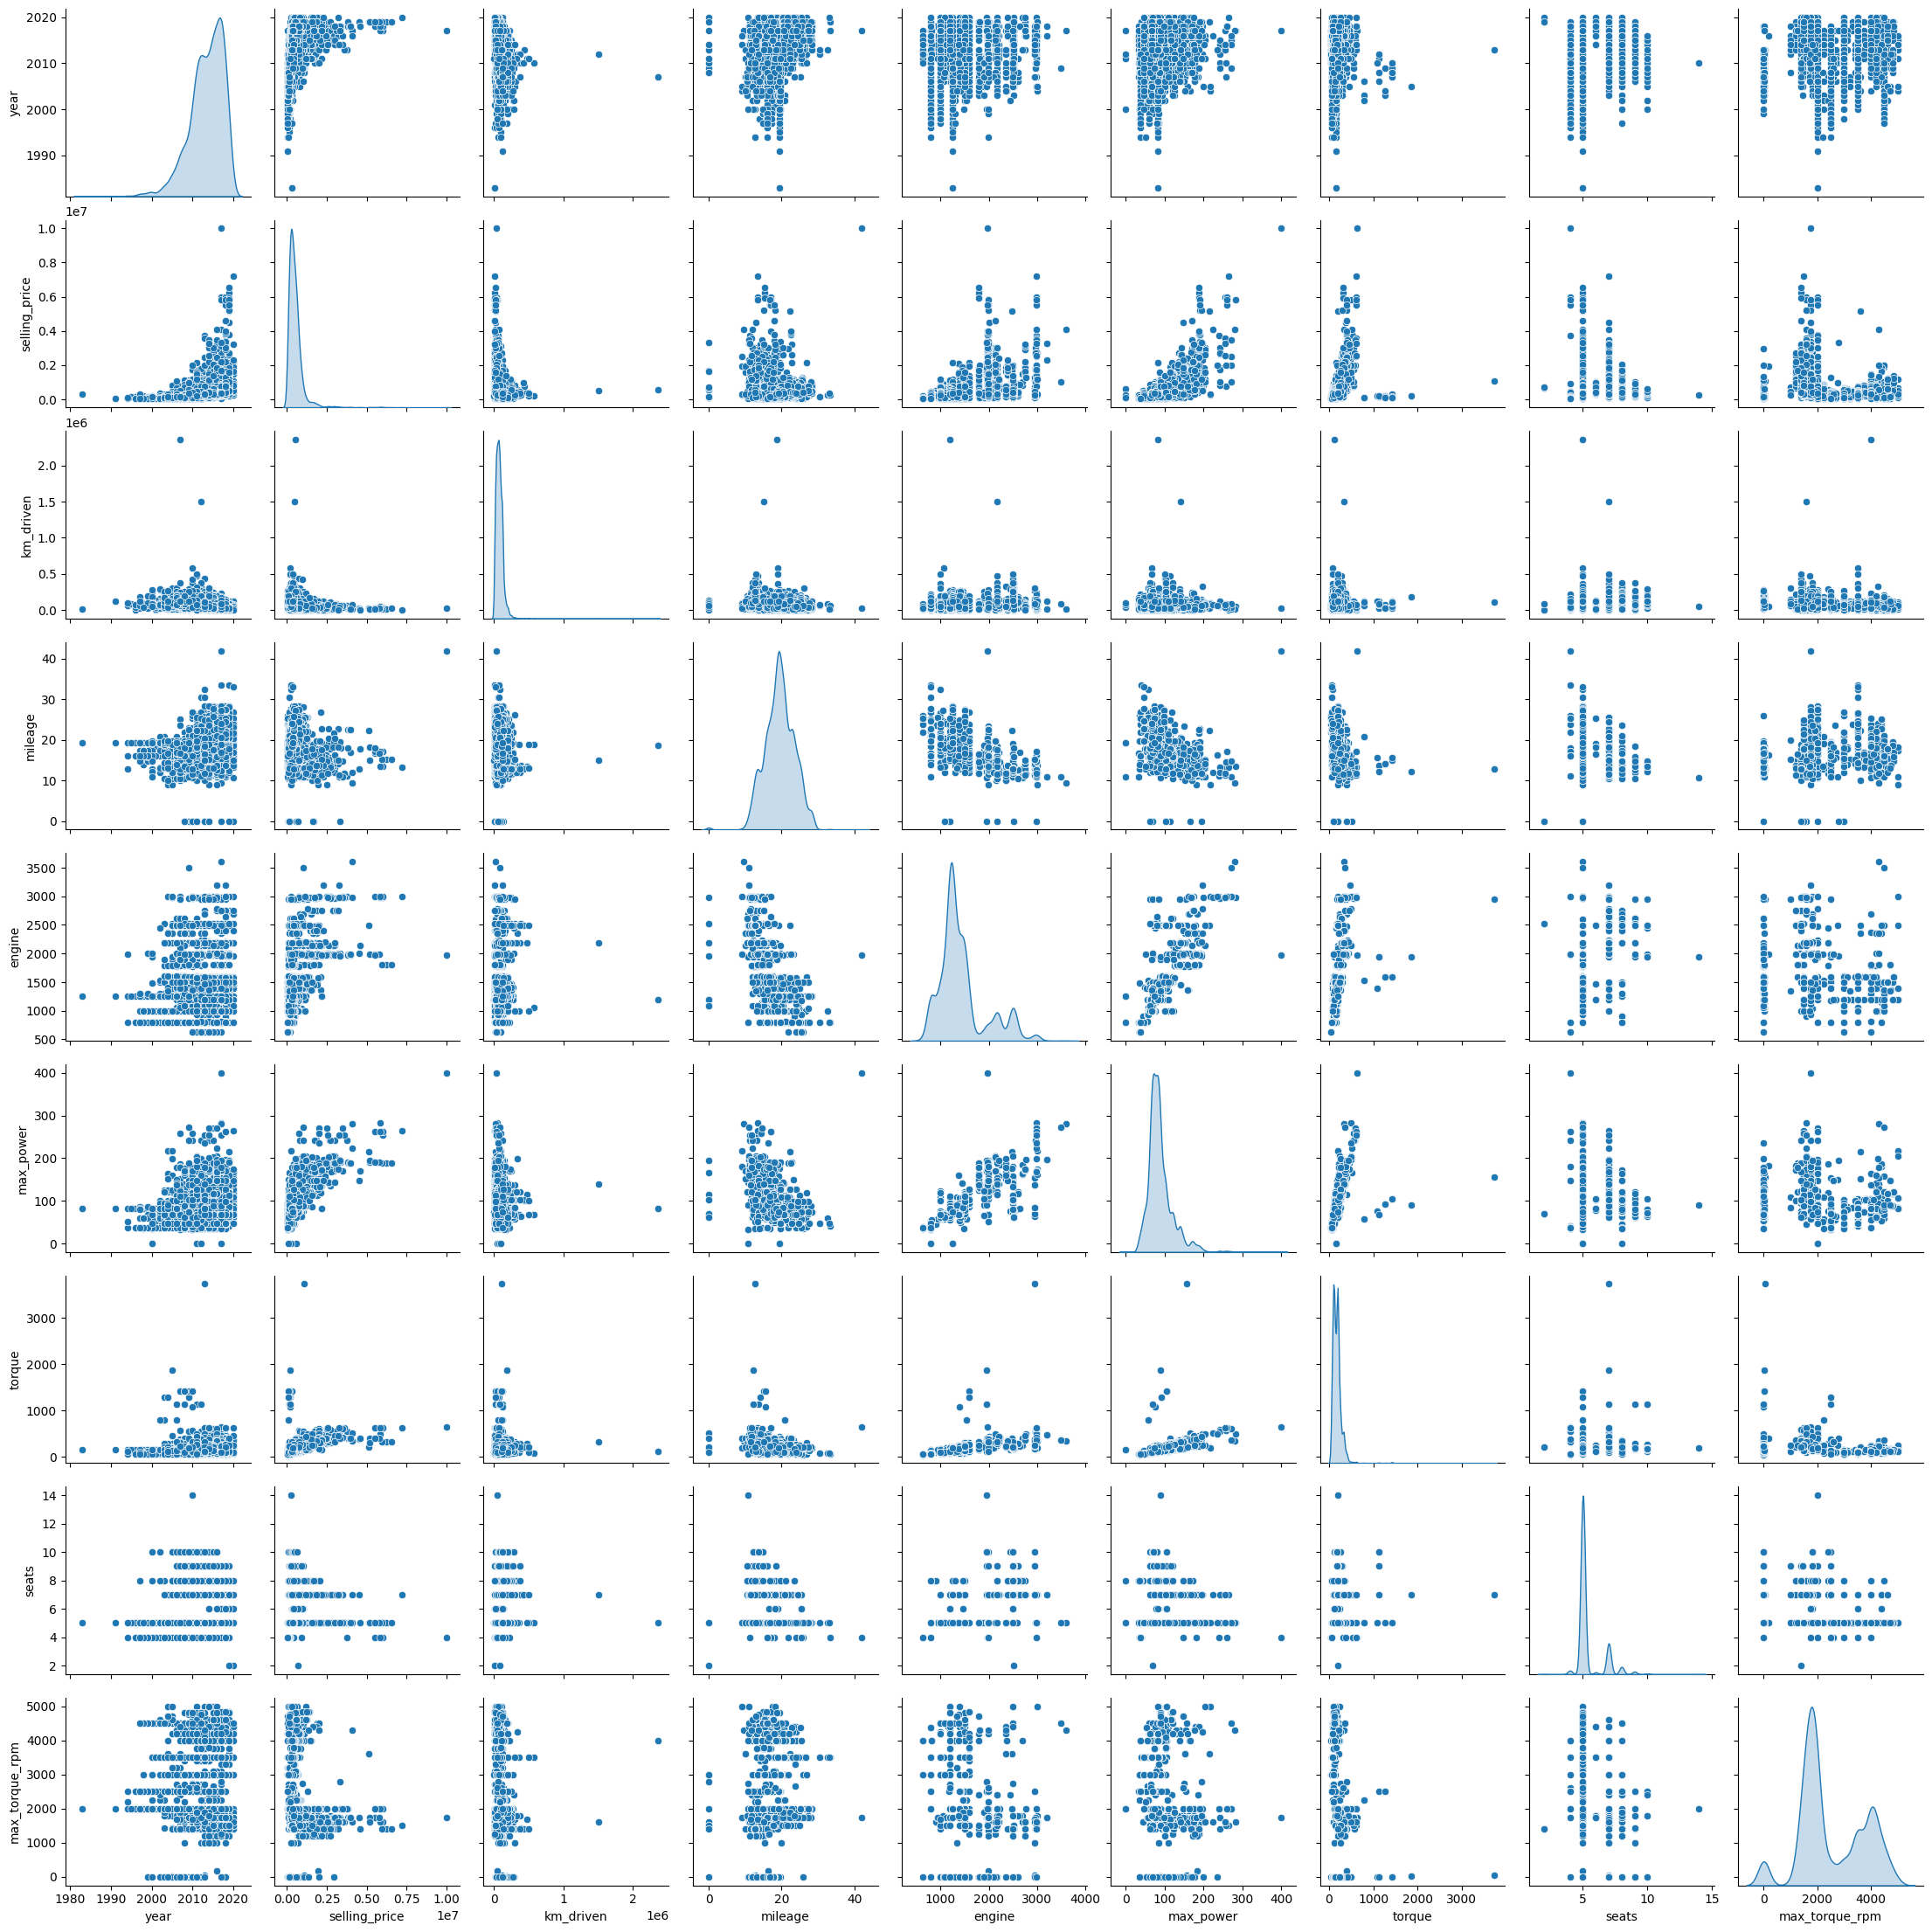

In [27]:
sns.pairplot(df_train.select_dtypes(include=['int64', 'float64']), diag_kind='kde')
plt.show()

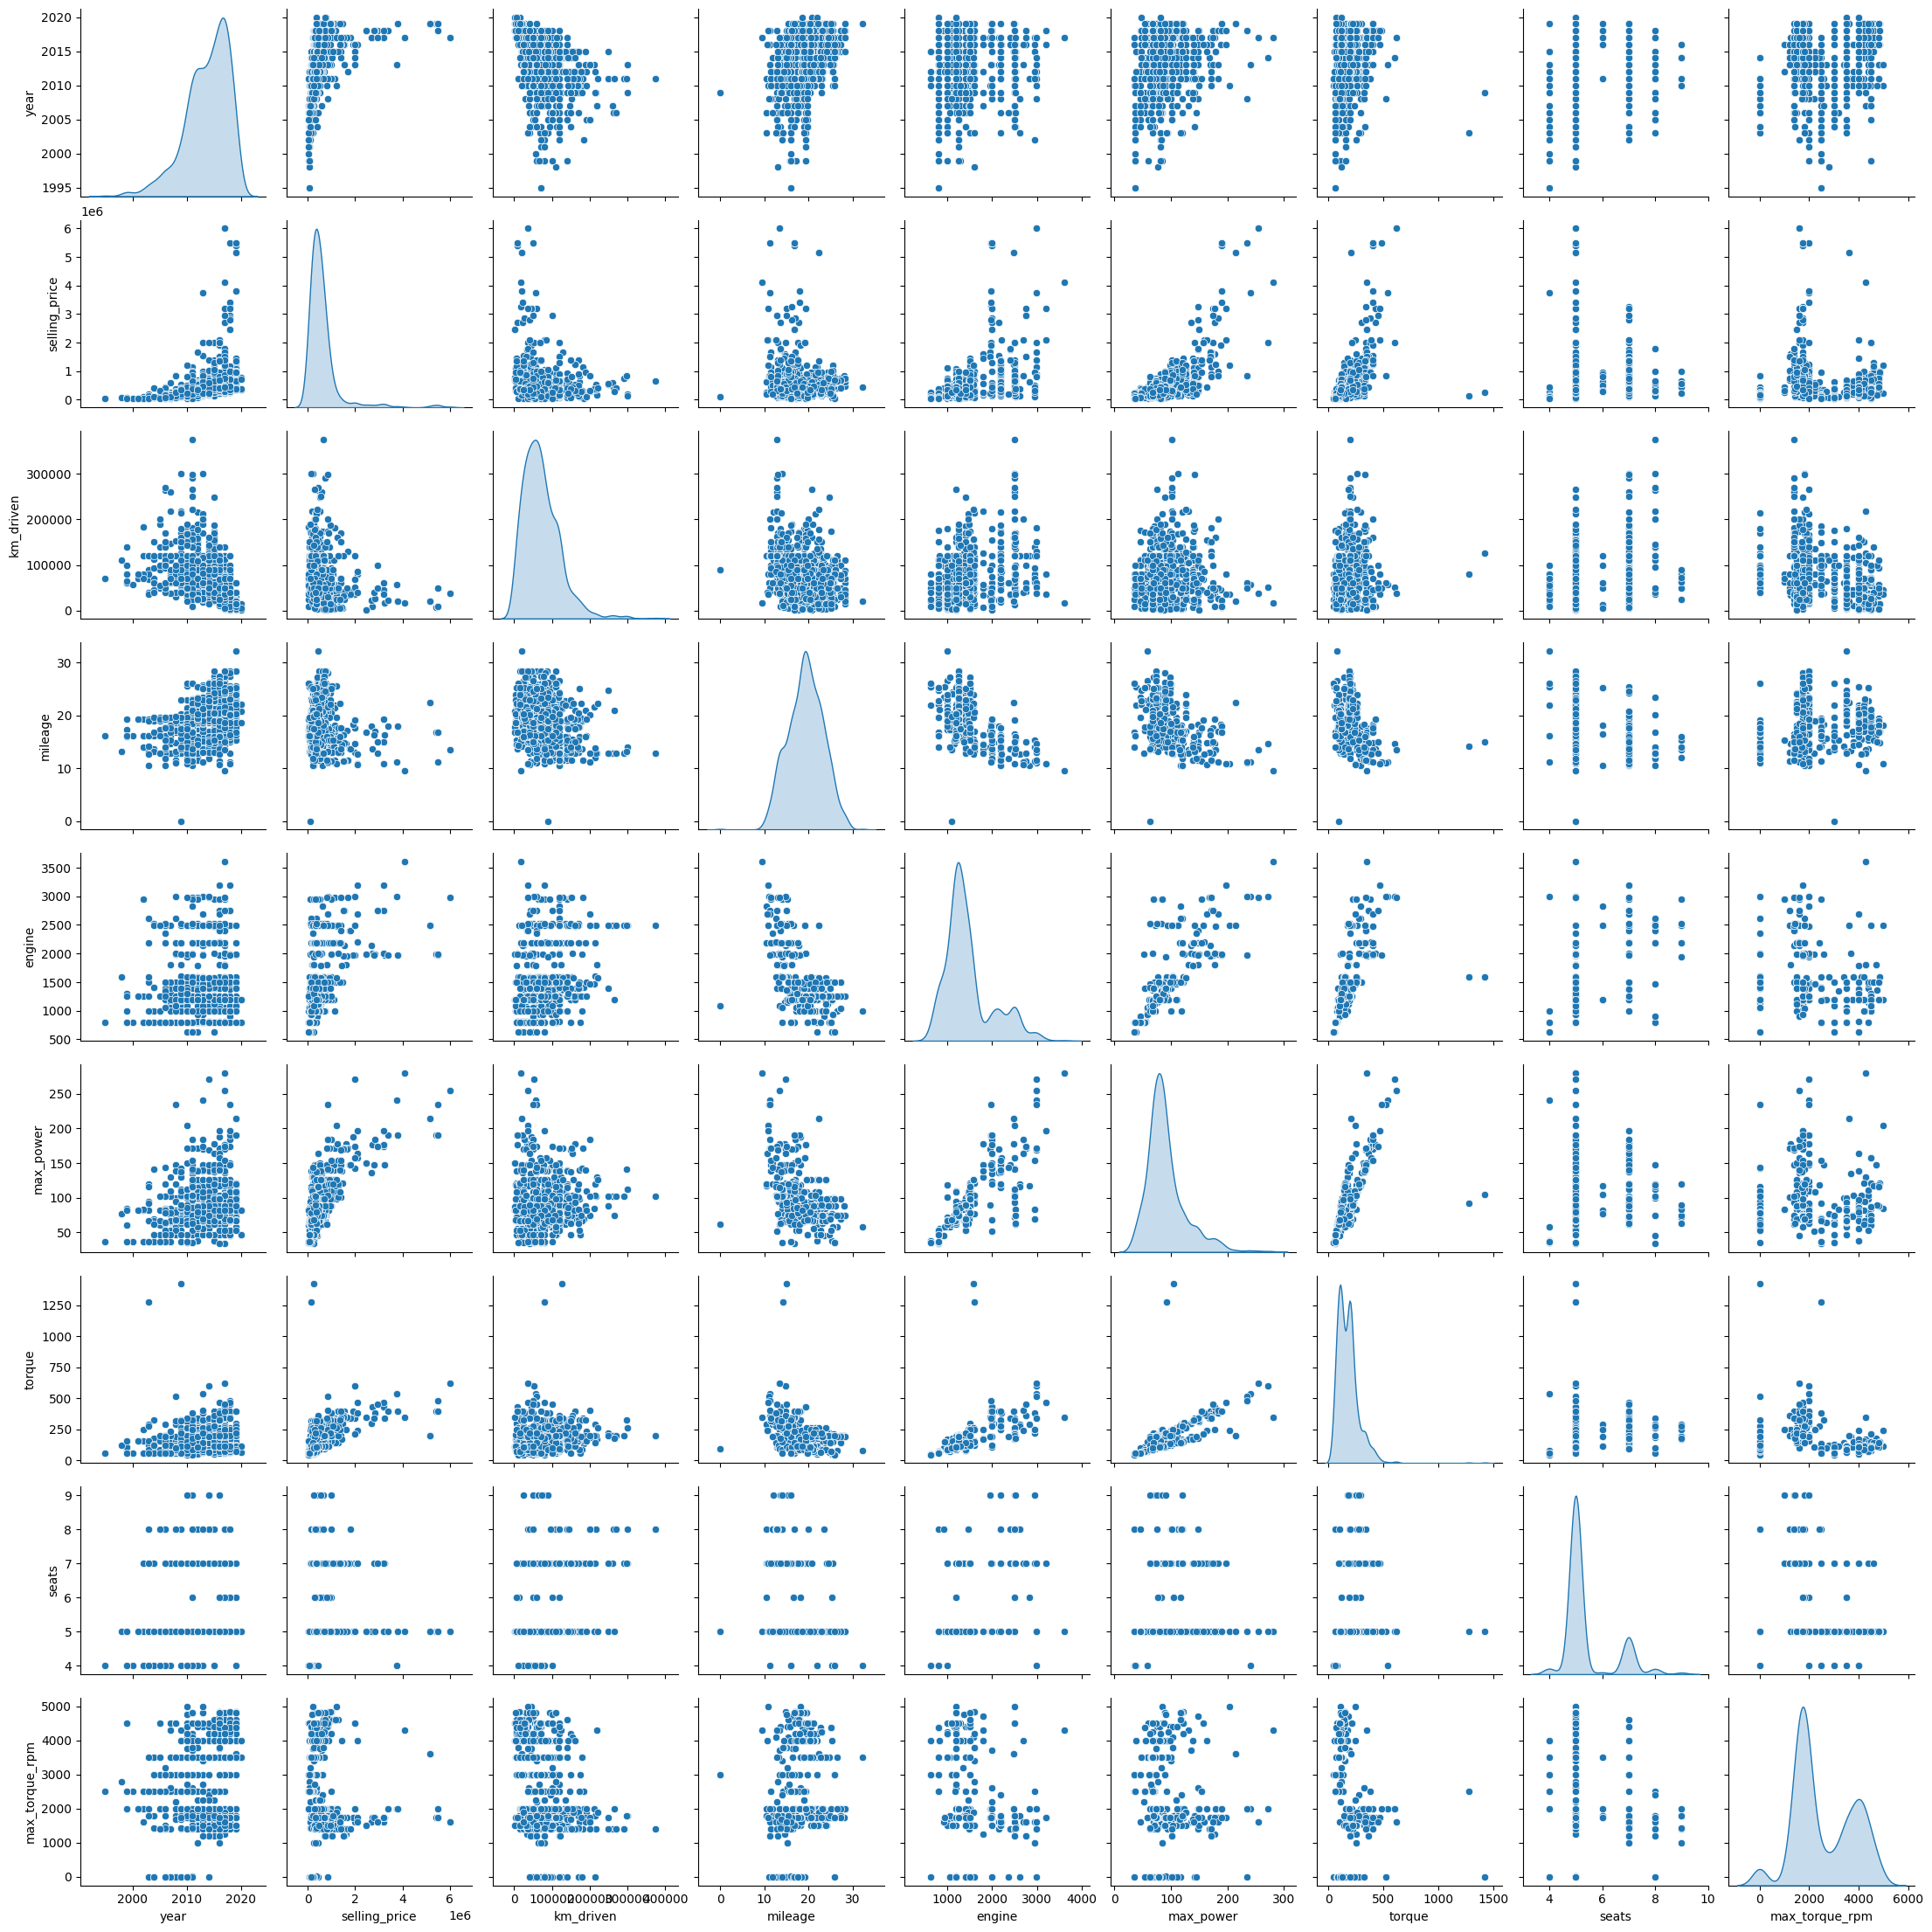

In [28]:
sns.pairplot(df_test.select_dtypes(include=['int64', 'float64']), diag_kind='kde')
plt.show()

### **Задание 9 (0.5 балла)**

И так, вы выдвинули гипотезы о наличии связи. Теперь давайте оценим эту связь в числах.

**Задание:**
- [ ] Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи `pd.corr()`
- [ ] По полученным корреляциям постройте тепловую карту (`heatmap` из бибилотеки seaborn)

In [29]:
df_train.select_dtypes(include=['int64', 'float64']).corr()

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
year,1.000000,0.427279,-0.368966,0.341334,0.002819,0.158207,0.048262,0.041178,0.162739
selling_price,0.427279,1.000000,-0.164828,-0.104769,0.447672,0.692725,0.433124,0.149953,-0.154424
km_driven,-0.368966,-0.164828,1.000000,-0.182086,0.229766,0.024379,0.106602,0.192328,-0.272061
mileage,0.341334,-0.104769,-0.182086,1.000000,-0.572893,-0.372197,-0.226219,-0.451059,0.093808
engine,0.002819,0.447672,0.229766,-0.572893,1.000000,0.681247,0.566066,0.652172,-0.452671
max_power,0.158207,0.692725,0.024379,-0.372197,0.681247,1.000000,0.615853,0.242791,-0.230176
torque,0.048262,0.433124,0.106602,-0.226219,0.566066,0.615853,1.000000,0.298097,-0.455409
seats,0.041178,0.149953,0.192328,-0.451059,0.652172,0.242791,0.298097,1.000000,-0.307137
max_torque_rpm,0.162739,-0.154424,-0.272061,0.093808,-0.452671,-0.230176,-0.455409,-0.307137,1.000000


<Axes: >

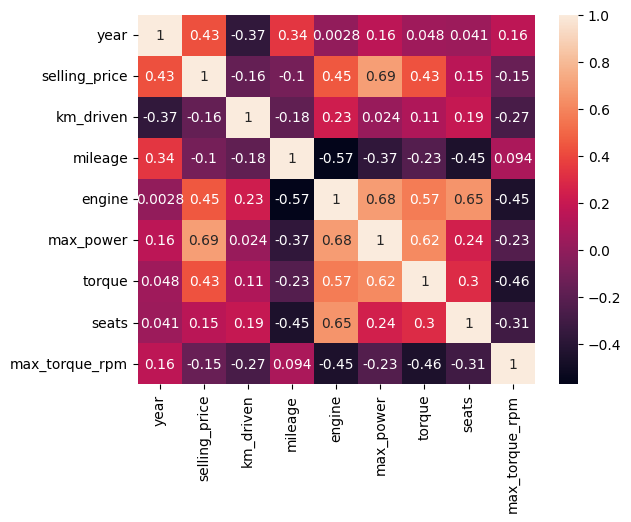

In [30]:
sns.heatmap(df_train.select_dtypes(include=['int64', 'float64']).corr(), annot=True)

- [ ] Ответьте на вопросы:
 - Какие 2 признака наименее скоррелированы между собой?
 - Между какими наблюдается довольно сильная положительная линейная зависимость?
 - Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?
 - Изучите типы корреляций в `pd.corr()`. Какую вы использовали по умолчанию?

Наименее коррелированными оказались признаки engine и year — их коэффициент практически нулевой, что показывает отсутствие какой-либо линейной связи между объёмом двигателя и годом выпуска автомобиля.
Сильные положительные корреляции наблюдаются между техническими характеристиками: engine - max_power, engine - torque, max_power - selling_price, engine - seats (все около 0.65–0.70). Это отражает вполне логичную закономерность: большие и мощные двигатели дают больше крутящего момента и увеличивают стоимость автомобиля.
Корреляция между year и km_driven отрицательная (около –0.37), поэтому в среднем можно утверждать, что чем старше автомобиль, тем выше его пробег. Связь умеренная, поэтому исключения возможны, но тенденция однозначно присутствует.
Корреляция, вычисленная функцией pd.corr() по умолчанию, — это коэффициент Пирсона, измеряющий силу линейной зависимости между числовыми признаками.

### **Задание 10 (0.6 балла)**

По умолчанию `pd.corr` возвращает корреляцию Пирсона, говорящую о линейной взаимосвязи. Но зависимости существуют не только линейные! В этой задаче, попробуйте измерить другие способы вычисления корреляций.

- [ ] Реализуйте корреляцию Спирмена/Кендала (на выбор) без использования библиотек (можно пользоваться только `numpy`). Сравните результаты вычисления с библиотечной реализацией
- [ ] Сделайте выводы


Постройте матрицу корреляции [phik](https://pypi.org/project/phik/)
- [ ] Проинтерпретируйте результаты


In [31]:
import phik

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable name is large: 1924. Are you sure this is not an interval variable? Analysis for pairs of variables including name can be slow.
  warnings.warn(


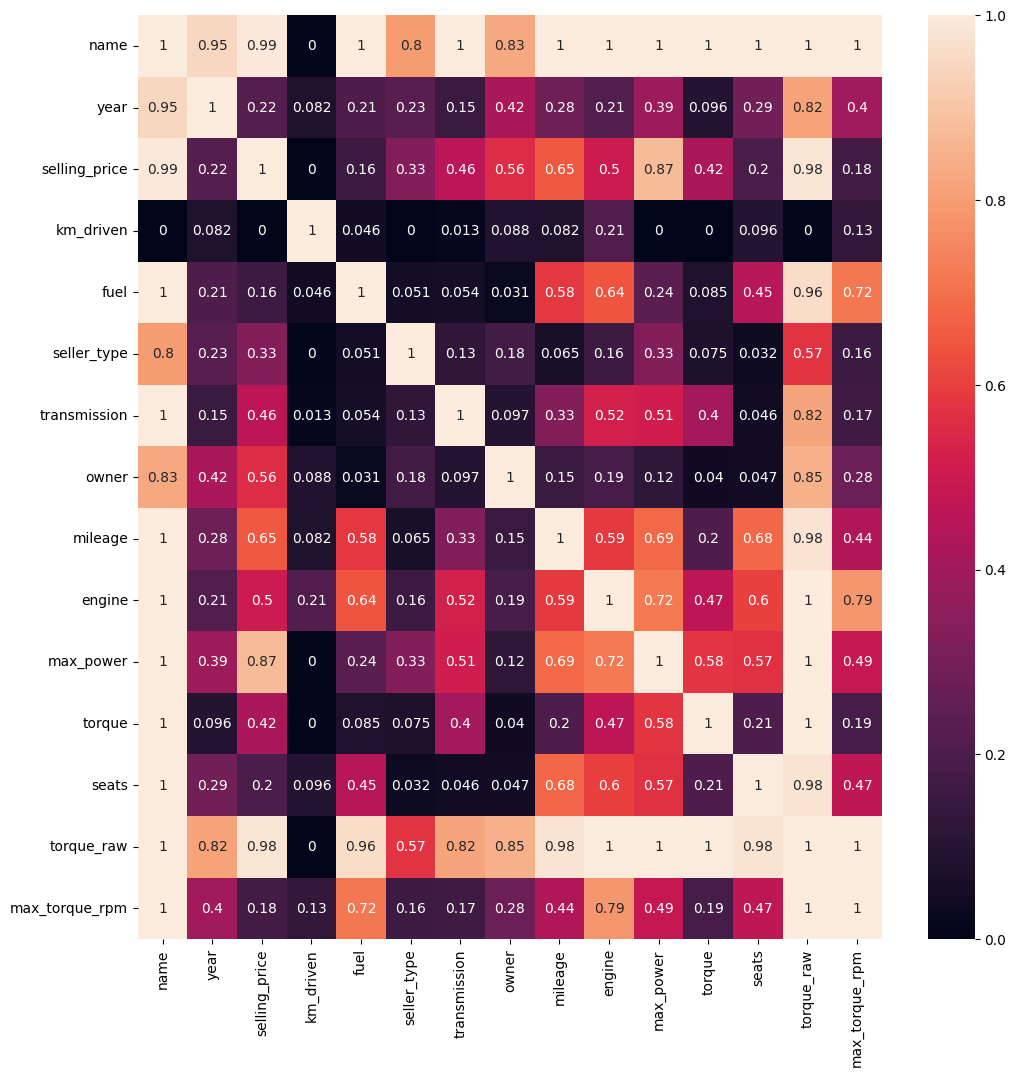

In [32]:
plt.figure(figsize=(12,12))
sns.heatmap(df_train.phik_matrix(df_train.select_dtypes(include=['int64', 'Float64'])), annot=True)
plt.show()

In [33]:
def spearman_simple(x, y):
    rx = np.argsort(np.argsort(x))
    ry = np.argsort(np.argsort(y))

    return np.corrcoef(rx, ry)[0, 1]

In [34]:
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
n = len(num_cols)

spearman_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        spearman_matrix[i, j] = spearman_simple(
            df_train[num_cols[i]].values,
            df_train[num_cols[j]].values
        )

spearman_df = pd.DataFrame(spearman_matrix, index=num_cols, columns=num_cols)
spearman_df

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm
year,1.000000,0.703601,-0.565952,0.345474,-0.038444,0.164979,0.100995,0.033749,0.098535
selling_price,0.703601,1.000000,-0.294737,0.026368,0.462023,0.612381,0.582304,0.228686,-0.234253
km_driven,-0.565952,-0.294737,1.000000,-0.198503,0.302458,0.041758,0.243272,0.157921,-0.333809
mileage,0.345474,0.026368,-0.198503,1.000000,-0.428339,-0.308199,-0.162186,-0.298647,0.143809
engine,-0.038444,0.462023,0.302458,-0.428339,1.000000,0.710660,0.839296,0.383174,-0.585367
max_power,0.164979,0.612381,0.041758,-0.308199,0.710660,1.000000,0.778597,0.221518,-0.315803
torque,0.100995,0.582304,0.243272,-0.162186,0.839296,0.778597,1.000000,0.327848,-0.673242
seats,0.033749,0.228686,0.157921,-0.298647,0.383174,0.221518,0.327848,1.000000,-0.309932
max_torque_rpm,0.098535,-0.234253,-0.333809,0.143809,-0.585367,-0.315803,-0.673242,-0.309932,1.000000


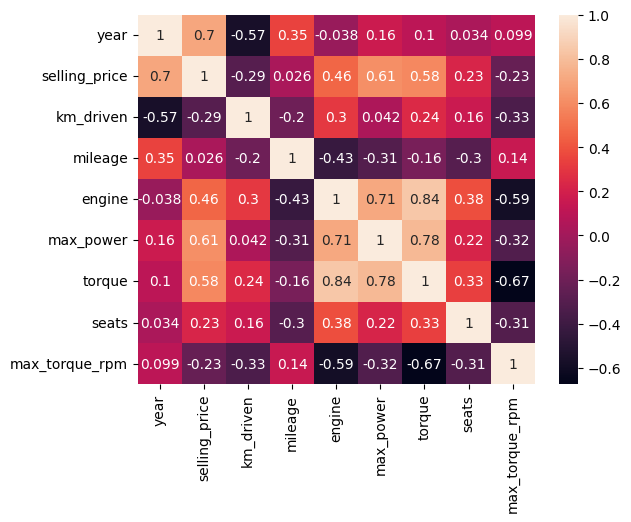

In [35]:
sns.heatmap(spearman_df, annot=True)
plt.show()

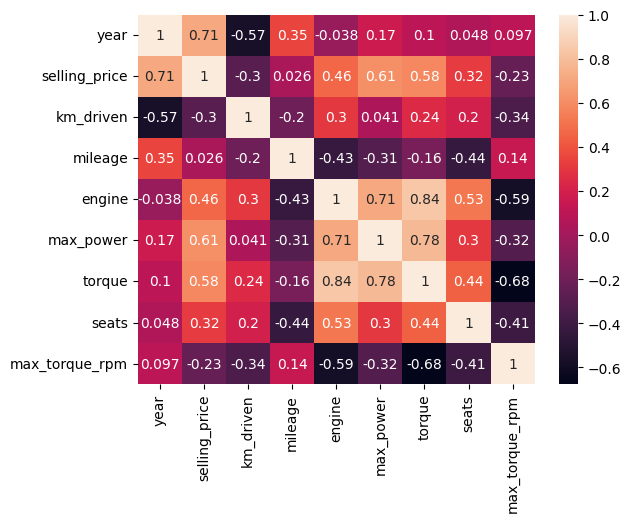

In [36]:
spearman_df_lib = df_train.select_dtypes(include=['Int64','float64']).corr(method='spearman')
sns.heatmap(spearman_df_lib, annot=True)
plt.show()


У нас есть незначительные отличия при реализации спирмана в ручную и через пандас,
Про пхик и спирмана
Он смотрит монотонность в целом,но если зависимость U-образная, цикличная, ступенчатая или категориальная Спирман её не увидит. 
PHIK измеряет любую зависимость: линейную, нелинейную, ступенчатую, пороговую, категориальную, смешанную.

### **Дополнительные визуализации (бонус 0.25 балла)**

Если вам кажется, что мы не попросили вас нарисовать какие-то очень важные зависимости, нарисуйте их и поясните.
Один график: 0.125 балла, при условии, что он обоснован.

In [37]:
# your code here

# **Часть 2 (1.7 балла) | Модель только на вещественных признаках**

В этой части вам предстоит обучить модель только на вещественных признаках. Почему только на них?

Чем больше признаковое пространство — чем сложнее модель. А чем модель проще — тем лучше для скорости работы и интерпретации признаков.

За задания этой части вы можете набрать 1.7 основных и 0.15 бонусных балла;

### **Задание 11 (0.05 балла)**

Разбейте данные на тренировочный и тестовый наборы. Перед разбиением создайте копию датафрейма, который будет хранить только вещественные признаки и используйте его (то есть категориальные столбцы (все, кроме seats) необходимо удалить).

В переменные y_train и y_test запишите значения целевых переменных.

In [38]:
import sklearn
from sklearn.model_selection import train_test_split

In [39]:
df_train

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,torque_raw,max_torque_rpm
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190.000000,5.0,190Nm@ 2000rpm,2000.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250.000000,5.0,250Nm@ 1500-2500rpm,1500.0
2,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,219.668960,5.0,22.4 kgm at 1750-2750rpm,1750.0
3,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,112.776475,5.0,"11.5@ 4,500(kgm@ rpm)",4.0
4,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,113.750000,5.0,113.75nm@ 4000rpm,4000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5835,Hyundai Santro Xing GLS,2008,120000,191000,Petrol,Individual,Manual,First Owner,17.92,1086.0,62.10,96.100000,5.0,96.1Nm@ 3000rpm,3000.0
5836,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.90,998.0,67.10,90.000000,5.0,90Nm@ 3500rpm,3500.0
5837,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,113.700000,5.0,113.7Nm@ 4000rpm,4000.0
5838,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110.00,235.359600,5.0,"24@ 1,900-2,750(kgm@ rpm)",1.0


In [40]:
X_train, y_train = df_train[df_train.select_dtypes(include=['int64', 'float64']).columns.to_list() + ['seats']].drop(columns='selling_price'), df_train['selling_price']

In [42]:
assert X_train.shape == (5840, 6)

AssertionError: 

In [43]:
X_test, y_test =  df_test[df_test.select_dtypes(include=['int64', 'float64']).columns.to_list() + ['seats']].drop(columns='selling_price'), df_test['selling_price']

In [44]:
assert X_test.shape == (1000, 6)

AssertionError: 

### **Задание 12. (0.2 балла)**

Построим нашу первую модель!
- [ ] Обучите классическую линейную регрессию с дефолтными параметрами. Посчтитайте $R^2$ и $MSE$ для трейна и для теста.
- [ ] Сделайте выводы по значениям метрик качества.

**Примечание:**

Здесь и далее $R^2$ и $MSE$ для трейна и для теста выводите везде, где требуется обучать модели, даже если в явном виде этого не просят. Иначе непонятно, как понять, насколько успешны наши эксперименты.

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import TargetEncoder

In [46]:
# encoder = TargetEncoder()

# X_train_encoded = pd.DataFrame(
#     encoder.fit_transform(X_train, y_train),
#     index=X_train.index
# )

# X_test_encoded = pd.DataFrame(
#     encoder.transform(X_test),
#     index=X_test.index
# )

# feature_names = X_train_encoded.columns

In [47]:
line_models = LinearRegression()
line_models.fit(X_train, y_train)

predict_data = line_models.predict(X_test)

print(f'MSE:{mean_squared_error(y_test,predict_data)}| R2_score:{r2_score(y_test,predict_data)}',)

MSE:232846356467.10938| R2_score:0.5949290372178986


### **Задание 13 (0.15 балла)**

- [ ] Реализуйте $R^2$ руками. Приведите формулу $R^2$ и объясните каждую компоненту метрики

In [48]:
def r2(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    y_mean = np.mean(y_true)

    ss_res = np.sum((y_true - y_pred)**2)

    ss_tot = np.sum((y_true - y_mean)**2)

    return 1 - ss_res / ss_tot

print("R2:", r2(y_test, predict_data))


R2: 0.5949290372178986


y_mean Среднее реальных значений
SS_res — ошибка модели
SS_tot — разброс реальных данных

### **Бонус (0.15 балла)**

- [ ] Реализуйте [$\text{adjusted}-R^2$](https://en.wikipedia.org/wiki/Coefficient_of_determination).
- [ ] Объясните, когда применяется $\text{adjusted}-R^2$?

In [49]:
def adjusted_r2(y_true, y_pred, n_features):
    n = len(y_true)
    r2_val = r2(y_true, y_pred)
    return 1 - (1 - r2_val) * (n - 1) / (n - n_features - 1)

print("Adjusted R2 (manual):", adjusted_r2(y_test, predict_data, X_test.shape[0]))

Adjusted R2 (manual): 405.6658918193193


если нужно понять, действительно ли новый признак улучшает модель

### **Задание 14 (0.05 балла)**

Всегда есть место совершенству. Поэтому давайте попробуем улучшить модель. При помощи стандартизации признаков.

- [ ] Стандартизируйте значения в тренировочных и тестовых данных. Стандартизатор **обучайте только на `train`**.

In [50]:
from sklearn.preprocessing import StandardScaler


In [51]:
scaler = StandardScaler()
scaled_data_X = scaler.fit_transform(X_train)


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
line_models.fit(X_train_scaled, y_train)
predict_data = line_models.predict(X_test_scaled)
print(f'MSE:{mean_squared_error(y_test,predict_data)}| R2_score:{r2_score(y_test,predict_data)}',)

MSE:232846356467.107| R2_score:0.5949290372179028


### **Задание 15 (0.1 балла)**

Хотя стандартизация не помогла сильно прибавить в качестве она открыла возможность интерпретировать важность признаков в модели. Правило интерпретации такое:

Чем больше коэффициент $\beta_i$ по модулю, тем важнее признак.

**Ответьте на вопрос:**

- [ ] Какой признак оказался наиболее информативным в предсказании цены?

In [53]:
coeffs = line_models.coef_

coef_table = pd.DataFrame({
    "feature": X_train.columns,
    "beta": coeffs,
    "abs_beta": np.abs(coeffs)
})

coef_table.sort_values("abs_beta", ascending=False).head()

,feature,beta,abs_beta
4,max_power,322232.860905,322232.860905
0,year,163415.471025,163415.471025
1,km_driven,-47826.619085,47826.619085
7,max_torque_rpm,-40111.775965,40111.775965
3,engine,34220.411196,34220.411196


In [54]:
# max_power - самый информативный

### **Задание 16 (0.25 балла)**

Попробуем улучшить нашу модель с помощью применения регуляризации. Для этого воспльзуемся `Lasso` регрессией.  Кроме того, попробуйте использовать её теоретическое свойство отбора признаков, за счет зануления незначимых коэффициентов.

**Задание:**

- [ ] Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
- [ ] Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.

In [55]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV


In [56]:
lasso = Lasso(alpha=1.0, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso MSE:", mean_squared_error(y_test, y_pred_lasso))
print("Lasso R2 :", r2_score(y_test, y_pred_lasso))

Lasso MSE: 232847040894.39206
Lasso R2 : 0.5949278465545679


In [57]:
coeffs = lasso.coef_
zero_coeffs = np.sum(coeffs == 0)

print("Всего признаков:", len(coeffs))
print("Занулённых коэффициентов:", zero_coeffs)
print("Доля занулённых:", zero_coeffs / len(coeffs))


Всего признаков: 9
Занулённых коэффициентов: 0
Доля занулённых: 0.0


### **Задание 17. Финальный рывок (0.4 балла)**

До этого мы с вами использовали `train` для обучения и `test` для прогнозирования. Но у нас есть ещё одна задача — подобрать оптимальные параметры модели. Для этого используем кросс-валидацию, описанную на семинарах.

Кроме того, выжмем максимум из модификаций регрессии. Построим `ElasticNet`. И сделаем всё по порядку.

**Ваша задача 1:**

- [ ] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для Lasso-регрессии. Вам пригодится класс [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [ ] Ответьте на вопросы:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Что значит каждый параметр `param_grid`, который вы заполняли для `GridSearch`? Опишите каждый
 - Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

In [58]:
param_grid = {
    "alpha": np.logspace(-4, 2, 50),
}

lasso = Lasso(max_iter=10000)

grid = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=10,               
    scoring="neg_mean_squared_error",
    n_jobs=-1            
)

grid.fit(X_train_scaled, y_train)

print("Лучший alpha:", grid.best_params_["alpha"])
print("Лучшая оценка:", grid.best_score_)

Лучший alpha: 100.0
Лучшая оценка: -120847008923.46516


In [59]:
best_lasso = grid.best_estimator_

y_pred_best = best_lasso.predict(X_test_scaled)

print("Test MSE:", mean_squared_error(y_test, y_pred_best))
print("Test R2:", r2_score(y_test, y_pred_best))

Test MSE: 232914876017.17902
Test R2: 0.5948098372418404


In [60]:
np.sum(best_lasso.coef_ == 0)

np.int64(0)

Ответы:
моделей = количество значений alpha × количество фолдов 50 × 100 = 500 моделей
param_grid = {
    "alpha": np.logspace(-4, 2, 50)
}
alpha - параметр регуляризации L1 управляет степенью зануления коэффициентов
маленький alpha - слабая регуляризация большой alpha - сильное зануление весов

Lasso может обнулить много коэффициентов
np.logspace(-4, 2, 50)

генерирует 50 значений от 1e-4 до 1e+2 (очень широкая сетка)

логарифмический шаг равномерно исследует разные порядки величин
лучшая модель имеет 100.0
 4. Занулились ли какие-нибудь веса?
Нет, веса были изначально очень большими

**Ваша задача 2:**

- [ ] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) регрессии.
- [ ] Ответьте на вопрос:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

In [61]:
from sklearn.linear_model import ElasticNet


In [62]:
param_grid = {
    "alpha": np.logspace(-4, 2, 20),    
    "l1_ratio": np.linspace(0.0, 1.0, 11),
}

elastic = ElasticNet(max_iter=20000)

grid = GridSearchCV(
    estimator=elastic,
    param_grid=param_grid,
    cv=10,                               
    scoring="neg_mean_squared_error",
    n_jobs=-1                          
)

grid.fit(X_train_scaled, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучшая оценка:", grid.best_score_)

Лучшие параметры: {'alpha': np.float64(0.01623776739188721), 'l1_ratio': np.float64(0.5)}
Лучшая оценка: -120841649904.36252


Для подбора гиперпараметров ElasticNet использовался GridSearchCV с 10-фолдовой кросс-валидацией.
В сетку параметров вошли:
alpha — сила регуляризации (перебиралась по логарифмической шкале np.logspace(-4, 2, 20)),
l1_rati — доля L1-штрафа в ElasticNet (линейная сетка np.linspace(0, 1, 11)).
Всего комбинаций гиперпараметров:
20 значений alpha × 11 значений l1_ratio = 220 комбинаций.
С учётом 10 фолдов GridSearch обучил:
220 × 10 = 2200 моделей ElasticNet.
Лучшие найденные параметры:
alpha = 0.01623776739188721
l1_ratio = 0.5

### **Задание 18 (0.35 балла)**

И так, вы обучили все варианты регуляризаций, доступные в sklearn, но не все, что мы обсудили на занятии! И следующее задание о забытой - $L0$ регуляризации.


**Ваша задача:**>
- [ ] Реализуйте модель с $L0$-регуляризаицей.
- [ ] Обучите модель на данных и проанализируйте результат, экспериментируя с коэффициенитом регуляризации
- [ ] Проанализируйте результаты обучения

**Важно:**

Вопреки тому, что L0 не реализована в стандартных пакетах, концепция данной регуляризации не является мертвой. Она может встречаться в [статьях](https://arxiv.org/abs/1712.01312) и экспериментах.



In [63]:
class L0Regression:
    def __init__(self, k=50, iters=200):
        self.k = k
        self.iters = iters

    def fit(self, X, y):
        n, d = X.shape
        w = np.zeros(d)

        L = np.linalg.norm(X, ord=2)**2
        step = 1 / L

        for _ in range(self.iters):
            grad = -2 * X.T @ (y - X @ w)
            
            w = w - step * grad

            idx = np.argsort(np.abs(w))[::-1]
            mask = np.zeros_like(w, dtype=bool)
            mask[idx[:self.k]] = True
            w = w * mask  

        self.coef_ = w
        self.intercept_ = 0

    def predict(self, X):
        return X @ self.coef_


In [64]:
for k in [10, 20, 50, 100, 200]:
    model = L0Regression(k=k, iters=300)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(k, "R2:", r2_score(y_test, y_pred))
    print("L0 MSE:", mean_squared_error(y_test, y_pred))



10 R2: -0.0895361595659303
L0 MSE: 626296496919.1414
20 R2: -0.0895361595659303
L0 MSE: 626296496919.1414
50 R2: -0.0895361595659303
L0 MSE: 626296496919.1414
100 R2: -0.0895361595659303
L0 MSE: 626296496919.1414
200 R2: -0.0895361595659303
L0 MSE: 626296496919.1414


# **Часть 3 (0.5 балла) | Добавляем категориальные фичи**

Попробуем для улучшения модели дать ей больше признаков. Добавим категориальные фичи.

За эту часть можно набрать 0.5 основных балла.



### **Задание 19 (0.1 балла)**

Проанализируйте столбец `name`. Очевидно, что эта переменная является категориальной, однако категорий в ней много.

- [ ] Предобработайте столбец `name`, чтобы избежать его удаления

In [65]:
X_train_cat = df_train.drop(columns=['selling_price', 'torque_raw'])
X_test_cat  = df_test.drop(columns=['selling_price', 'torque_raw'])

y_train = df_train['selling_price']
y_test  = df_test['selling_price']


In [66]:
X_train_cat.shape

(5840, 13)

In [67]:
assert X_train_cat.shape == (5840, 11)

AssertionError: 

In [68]:
# я до этого по-другому признаки собрал, поэтому у меня и больше их

In [69]:
X_train_cat.describe(include='object')

,name,fuel,seller_type,transmission,owner
count,5840,5840,5840,5840,5840
unique,1924,4,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,91,3177,5223,5336,3603


### **Задание 20 (0.1 балла)**

- [ ] Закодируйте категориалльные фичи и ``seats`` методом OneHot-кодирования.

In [70]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = X_train_cat.select_dtypes(include=['object']).columns
num_cols = X_train_cat.select_dtypes(include=['int64', 'float64']).columns

cat_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

cat_features = cat_cols.to_list() + ['seats']

X_train_cat_encoded = cat_transformer.fit_transform(X_train_cat[cat_features])
X_test_cat_encoded = cat_transformer.transform(X_test_cat[cat_features])

cat_feature_names = cat_transformer.get_feature_names_out(cat_features)

X_train_prepared = pd.DataFrame(
    data=np.hstack([X_train_cat[num_cols].values, X_train_cat_encoded]),
    columns=list(num_cols) + list(cat_feature_names)
)

X_test_prepared = pd.DataFrame(
    data=np.hstack([X_test_cat[num_cols].values, X_test_cat_encoded]),
    columns=list(num_cols) + list(cat_feature_names)
)

### **Задание 21 (0.2 балла)**

OHE — базовый алгоритм преобразования категориальных признаков, но и с ним нужно быть аккуратными.

**Ответьте на вопросы:**


* Как корректно работать с OHE преобразованием?
* Почему мы удаляем один столбец?
* Пусть из $n$ признаков мы получили $n-1$ столбец, из которых $k < n -1$ оказались не важными по весам модели. Корректно ли их удалить?

Корректная работа с OHE заключается в том, что кодировщик обучают только на тренировочной выборке и затем применяют к тестовой, чтобы избежать утечки данных. Также необходимо использовать режим handle_unknown='ignore', чтобы тестовые категории не ломали модель.

При OHE один столбец удаляют, потому что все бинарные индикаторы категории линейно зависимы: их сумма всегда равна 1. Это приводит к мультиколлинеарности, от которой страдают линейные модели — веса становятся нестабильными и плохо интерпретируемыми. Удаление одного столбца (drop-first) убирает линейную зависимость.

Если из (n−1) полученных OHE-столбцов модель сочла важными только k, удалять неважные можно только после обучения, и только если используется регуляризация (L1/ElasticNet). В этом случае их удаление корректно, потому что L1 уже обнулит или почти обнулит соответствующие коэффициенты, и признак фактически не несёт полезной информации.

### **Задание 22 (0.1 балла)**
Повторим то, что делали на прошлом шаге для моделей на вещественных признаках, однако теперь с моделью `Ridge`.


**Ваша задача:**
- [ ] Переберите параметр регуляризации `alpha` для гребневой (ridge) регрессии с помощью класса `GridSearchCV` В качестве параметров при объявлении GridSearchCV кроме модели укажите метрику качества $R^2$. Кроссвалидируйтесь по 10-ти фолдам.
- [ ] Ответье на вопрос: Удалось ли улучшить качество прогнозов?

In [71]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

param_grid = {"alpha": np.logspace(-4, 3, 20)}

grid_ridge = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring="r2",
    cv=10,
    n_jobs=-1
)

grid_ridge.fit(X_train_prepared, y_train)
best_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_prepared)


print("Лучший alpha:", grid_ridge.best_params_["alpha"])
print("Лучший CV R2:", grid_ridge.best_score_)
print("Test R2:", r2_score(y_test, y_pred_ridge))
print("Test MSE:", mean_squared_error(y_test, y_pred_ridge))

Лучший alpha: 0.2069138081114788
Лучший CV R2: 0.7770144242442489
Test R2: 0.9385549923352156
Test MSE: 35320345007.14118


In [72]:
# Нет, не удалось

# **Часть 4 - бонусная (1 балл) | Feature Engineering**

В этой части домашнего задания вам предлагается проявить свою креативность для улучшения прогноза модели. Любые другие модели, кроме различных форм линейной (или полиномиальной) регресси, использовать запрещается. А значит, придется работать с признаками

**Что можно попробовать сделать?** (каждый пункт по 0.4 балла, но не больше 1-х балла в сумме)

1.   *Сгенерировать новые признаки на основе уже существующих:*
    * посчитать произведения // частные признаков (кажется, что посчитать число "лошадей" на литр объема может быть полезно);
    * имеет смысл обратить внимание на визуализации в части с EDA (к примеру, зависимость цены от года выглядит квадратичной, а не линейной; значит, квадрат года нам, скорее всего, принесет больше пользы)

2.   *Добыть новые признаки:*
    * имеем название автомобиля, которое никак не используем (можно спарсить инфу о классе автомобиля или каких-то специфических опциях)
    * можно добавить пороговые признаки вроде "владелец третий или больше" и объединить признаки в некоторые осмысленные правила, например "первый или второй владелец и продавец официальный дилер" (подбирать пороги удобно по диаграммам рассеяния)

3.   *Поработать с уже имеющимися:*
    * далеко не факт, что заполнить пропуск медианой было лучшей идеей (как минимум, можно добавить dummy-столбец для модели, сигнализирующий, что раньше на месте медианы был пропуск -- там где он был, конечно); попробуйте другие способы филлинга;
    * мы не анализировали, есть ли в данных выбросы => никак выбросы не обрабатывали; наиболее простым и, тем не менее, довольно полезным вариантом нахождения выбросов могут послужить boxplot'ы для каждого столбца; что делать с выбросами думайте сами :) -- вариантов довольно много
    * мы толком не смотрели на таргет сам по себе; в нем тоже могут быть неожиданности -- стоит хотя бы проверить
    * можно заметить, что некоторые признаки распределены совсем не нормально; возможно их стоит отлогарифмировать

И так далее...

Feel Free to Try!

In [73]:
max(X_train_prepared['year'])

2020.0

In [74]:
def create_new_features(df):
    df = df.copy()
    
    df['year_squared'] = df['year'] ** 2
    df['km_driven_squared'] = df['km_driven'] ** 2
    
    if 'engine' in df.columns and 'max_power' in df.columns:
        df['power_per_liter'] = df['max_power'] / df['engine']
        df['power_per_liter'].replace([np.inf, -np.inf], 0, inplace=True)
        df['power_per_liter'].fillna(0, inplace=True)
    
    if 'mileage' in df.columns and 'engine' in df.columns:
        df['fuel_efficiency_score'] = df['mileage'] * df['engine']
    
    if 'max_power' in df.columns and 'torque' in df.columns:
        df['power_torque_ratio'] = df['max_power'] / (df['torque'] + 1e-10)
    
    current_year = max(df['year'])  
    df['car_age'] = current_year - df['year']
    df['car_age_squared'] = df['car_age'] ** 2
    
    skewed_columns = ['km_driven', 'engine', 'max_power', 'torque']
    for col in skewed_columns:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(df[col])
    
    return df

In [75]:
X_train = create_new_features(X_train_prepared)
X_test= create_new_features(X_test_prepared)

C:\Users\Admin\AppData\Local\Temp\ipykernel_19904\4140589523.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['power_per_liter'].replace([np.inf, -np.inf], 0, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19904\4140589523.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [76]:
X_train

,year,km_driven,mileage,engine,max_power,torque,seats,max_torque_rpm,name_Ambassador CLASSIC 1500 DSL AC,name_Ambassador Classic 2000 DSZ AC PS,...,km_driven_squared,power_per_liter,fuel_efficiency_score,power_torque_ratio,car_age,car_age_squared,log_km_driven,log_engine,log_max_power,log_torque
0,2014.0,145500.0,23.40,1248.0,74.00,190.000000,5.0,2000.0,0.0,0.0,...,2.117025e+10,0.059295,29203.20,0.389474,6.0,36.0,11.887938,7.130099,4.317488,5.252273
1,2014.0,120000.0,21.14,1498.0,103.52,250.000000,5.0,1500.0,0.0,0.0,...,1.440000e+10,0.069105,31667.72,0.414080,6.0,36.0,11.695255,7.312553,4.649378,5.525453
2,2010.0,127000.0,23.00,1396.0,90.00,219.668960,5.0,1750.0,0.0,0.0,...,1.612900e+10,0.064470,32108.00,0.409707,10.0,100.0,11.751950,7.242082,4.510860,5.396664
3,2007.0,120000.0,16.10,1298.0,88.20,112.776475,5.0,4.0,0.0,0.0,...,1.440000e+10,0.067951,20897.80,0.782078,13.0,169.0,11.695255,7.169350,4.490881,4.734236
4,2017.0,45000.0,20.14,1197.0,81.86,113.750000,5.0,4000.0,0.0,0.0,...,2.025000e+09,0.068388,24107.58,0.719648,3.0,9.0,10.714440,7.088409,4.417152,4.742756
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5835,2008.0,191000.0,17.92,1086.0,62.10,96.100000,5.0,3000.0,0.0,0.0,...,3.648100e+10,0.057182,19461.12,0.646202,12.0,144.0,12.160034,6.991177,4.144721,4.575741
5836,2013.0,50000.0,18.90,998.0,67.10,90.000000,5.0,3500.0,0.0,0.0,...,2.500000e+09,0.067234,18862.20,0.745556,7.0,49.0,10.819798,6.906755,4.220977,4.510860
5837,2013.0,110000.0,18.50,1197.0,82.85,113.700000,5.0,4000.0,0.0,0.0,...,1.210000e+10,0.069215,22144.50,0.728672,7.0,49.0,11.608245,7.088409,4.429029,4.742320
5838,2007.0,119000.0,16.80,1493.0,110.00,235.359600,5.0,1.0,0.0,0.0,...,1.416100e+10,0.073677,25082.40,0.467370,13.0,169.0,11.686887,7.309212,4.709530,5.465354


In [77]:
grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)


print("Лучший alpha:", grid_ridge.best_params_["alpha"])
print("Лучший CV R2:", grid_ridge.best_score_)
print("Test R2:", r2_score(y_test, y_pred_ridge))
print("Test MSE:", mean_squared_error(y_test, y_pred_ridge))

Лучший alpha: 0.2069138081114788
Лучший CV R2: 0.8013610753031963
Test R2: 0.9461314244972457
Test MSE: 30965195450.548714


C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.8174e-28): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


# **Часть 4. | Бизнесовая (0.5 балла)**

### **Задание 23 (0.25 балла)**

В мире бизнеса очень важно давать оценку качества модели понятную бизнесу, поэтому иногда заказчики приходят с кастомными метриками. Попробуем сделать такую для нашей задачи.

**Описание метрики:**

Среди всех предсказанных цен на авто нужно посчитать долю прогнозов, отличающихся от реальных цен на эти авто не более чем на 10% (в одну или другую сторону)

**Ваша задача:**

- [ ] Реализуйте метрику `business_metric`
- [ ] Посчитайте метрику для всех обученных моделей и определеите, какаю лучше всего решает задачу бизнеса

In [78]:
def business_metrics(y_true, y_pred):

    persent_erroer = np.abs(y_true - y_pred)/y_pred
    result = np.mean(persent_erroer <= 0.1)
    
    return result


In [79]:
 # y_pred Моя самописная модель
# y_pred_lasso

for y in [y_pred, y_pred_lasso, y_pred_ridge]:
    print(business_metrics(y_test, y))

0.462
0.304
0.484


### **Задание 24 (0.25 балла)**

Но у бизнеса не всегда есть идеи и иногда задача на выбор метрики делегируется вам.

**Задание:**

- [ ] Придумайте и реализуйте другую кастомную метрику с учетом того, что модель не должна сильно ошибаться в прогнозе, но недопрогноз для модели, согласно мнению бизнеса, хуже, чем перепрогноз.
- [ ] Посчитайте метрику для всех обученных моделей и определеите, какаю лучше всего решает задачу бизнеса



In [80]:
def your_business_metrics(y_true, y_pred, under_penalty=2.0):

    
    errors = np.log(y_true) - np.log(y_pred)
    weights = np.where(errors > 0, under_penalty, 1.0)
    weighted_errors = np.abs(errors) * weights
    return np.mean(weighted_errors)


for y in [y_pred, y_pred_lasso, y_pred_ridge]:
    print(your_business_metrics(y_test, y))

2.626618725761089
0.5085673289286169
0.284890266293297


C:\Users\Admin\AppData\Local\Temp\ipykernel_19904\185390122.py:4: RuntimeWarning: invalid value encountered in log
  errors = np.log(y_true) - np.log(y_pred)


In [85]:
import pickle

model = grid_ridge.best_estimator_
pickle.dump(model, open('models_ridge.pkl', 'wb'))

# **Часть 6 (1 балл) | Оформление результатов**

### **Задание 25**

**Результаты вашей работы** необходимо разместить в своем Гитхабе. Далее в этот же репозиторий вы прикрепите вторую часть. Под результатами первой части понимаем следующее:
* ``.ipynb``-ноутбук со всеми проведёнными вами экспериментами (output'ы ячеек, разумеется, сохранить)
* ``.pickle``-файл с сохранёнными весами модели, коэффициентами скейлинга и прочими числовыми значениями, которые могут понадобиться для инференса
* ``.md``-файл с выводами про проделанной вами работе:
    * что было сделано
    * с какими результатами
    * что дало наибольший буст в качестве
    * что сделать не вышло и почему (это нормально, даже хорошо😀)

**За что могут быть сняты баллы в этом пункте:**
* за отсутствие ``.pickle``-файла с весами использованной модели
* за недостаточную аналитику в ``.md``-файле
* за оформление и логику кода (в определённом смысле это тоже элемент оформления решения)

In [91]:
X_train.select_dtypes(include=[ 'Float64']).columns.to_list()

['year',
 'km_driven',
 'mileage',
 'engine',
 'max_power',
 'torque',
 'seats',
 'max_torque_rpm',
 'name_Ambassador CLASSIC 1500 DSL AC',
 'name_Ambassador Classic 2000 DSZ AC PS',
 'name_Ambassador Grand 2000 DSZ PW CL',
 'name_Audi A3 35 TDI Premium Plus',
 'name_Audi A3 40 TFSI Premium',
 'name_Audi A4 1.8 TFSI',
 'name_Audi A4 2.0 TDI',
 'name_Audi A4 2.0 TDI 177 Bhp Premium Plus',
 'name_Audi A4 35 TDI Premium Plus',
 'name_Audi A6 2.0 TDI',
 'name_Audi A6 2.0 TDI  Design Edition',
 'name_Audi A6 2.0 TDI Technology',
 'name_Audi A6 35 TFSI Matrix',
 'name_Audi Q3 2.0 TDI Quattro Premium Plus',
 'name_Audi Q3 35 TDI Quattro Premium Plus',
 'name_Audi Q3 35 TDI Quattro Technology',
 'name_Audi Q5 2.0 TDI',
 'name_Audi Q5 3.0 TDI Quattro',
 'name_Audi Q5 35TDI Premium Plus',
 'name_Audi Q5 45 TDI quattro Technology',
 'name_Audi Q7 3.0 TDI Quattro',
 'name_Audi Q7 3.0 TDI Quattro Premium Plus',
 'name_Audi Q7 35 TDI Quattro Premium',
 'name_BMW 3 Series 320d',
 'name_BMW 3 Series 3